# Dummy Classifier Baseline - UNSW-NB15 Cybersecurity
## Simple Majority Class Baseline for Model Comparison

### Modell-Spezifikation
- **Datensatz:** UNSW_NB15_LEAKAGE_REMOVED (saubere Variante)
- **Features:** 25 raw network traffic metrics (keine Leakage-Features)
- **Zielvariable:** is_attack (0=Normal, 1=Attack)
- **Methode:** Dummy Classifier (Majority Class Strategy)
- **Zweck:** Baseline-Vergleich für Decision Tree und Logistic Regression

## 1. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

# Import helper functions from utils.py
from utils import (
    load_unsw_data,
    get_raw_network_features,
    get_feature_mapping,
    prepare_train_test_split,
    evaluate_binary_classifier
)

import warnings
warnings.filterwarnings('ignore')

# Matplotlib settings
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load LEAKAGE_REMOVED Data

In [2]:
# ===== LOAD CLEAN LEAKAGE_REMOVED DATA =====
train_data, test_data, df = load_unsw_data(
    train_file="UNSW_NB15_train_LEAKAGE_REMOVED.csv",
    test_file="UNSW_NB15_test_LEAKAGE_REMOVED.csv"
)

DATA LOADING SUCCESSFUL

Train Set: 65,865 samples x 59 features
Test Set:  16,467 samples x 59 features
Combined:  82,332 samples x 59 features



## 3. Data Overview

In [3]:
# ===== DATA OVERVIEW =====
print("="*80)
print("DATA OVERVIEW")
print("="*80)

print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names (alle {len(df.columns)} Features):")
print(df.columns.tolist())

print(f"\nData Types:")
print(df.dtypes.value_counts())

print(f"\nTarget Variable Distribution (is_attack):")
print(df['is_attack'].value_counts())
print(f"\n   Normal (0): {(df['is_attack']==0).sum():,} ({(df['is_attack']==0).sum()/len(df)*100:.1f}%)")
print(f"   Attack (1): {(df['is_attack']==1).sum():,} ({(df['is_attack']==1).sum()/len(df)*100:.1f}%)")

print(f"\nNo missing values: {df.isna().sum().sum() == 0}")

DATA OVERVIEW

Dataset Shape: (82332, 59)

Column Names (alle 59 Features):
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '45', '150', '156', '157', '171', '172', '173', '174', '178', '183', '184', '185', '186', '189', '190', '191', '192', '194', 'is_attack']

Data Types:
float64    58
int64       1
Name: count, dtype: int64

Target Variable Distribution (is_attack):
is_attack
1    45332
0    37000
Name: count, dtype: int64

   Normal (0): 37,000 (44.9%)
   Attack (1): 45,332 (55.1%)

No missing values: True


## 4. Feature Selection: Ultra-Raw Network Metrics

In [4]:
# ===== SELECT ONLY RAW NETWORK FEATURES (NO LEAKAGE) =====
print("="*80)
print("FEATURE SELECTION: ULTRA-RAW NETWORK METRICS")
print("="*80)

# Get raw network features using helper function
raw_network_features = get_raw_network_features()

print(f"\nFeatures behalten: {len(raw_network_features)}")
print(f"   {raw_network_features}")

# Create dataset with only raw features
df_clean = df[raw_network_features + ['is_attack']].copy()

print(f"\nClean Dataset: {df_clean.shape[0]:,} samples x {df_clean.shape[1]-1} features + target")

FEATURE SELECTION: ULTRA-RAW NETWORK METRICS

Features behalten: 25
   ['5', '6', '7', '8', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30']

Clean Dataset: 82,332 samples x 25 features + target


## 5. Prepare Feature Matrix and Target Variable

In [5]:
# ===== PREPARE X AND Y =====
# Using helper function for train/test split
X_train, X_test, y_train, y_test = prepare_train_test_split(df_clean, train_data)

TRAIN/TEST SPLIT (Using Original Dataset Boundaries)

Train Set: 65,865 samples
   Normal (0): 29,600 (44.9%)
   Attack (1): 36,265 (55.1%)

Test Set: 16,467 samples
   Normal (0): 7,400 (44.9%)
   Attack (1): 9,067 (55.1%)



## 6. Dummy Classifier Training (Stratified Random Baseline)

In [6]:
# ===== DUMMY CLASSIFIER TRAINING =====
print("="*80)
print("TRAINING DUMMY CLASSIFIER (STRATIFIED RANDOM BASELINE)")
print("="*80)

# Create and train dummy classifier
# Strategy='stratified': Respects class distribution from training set
# This is a fair baseline: randomly predicts with same probabilities as training data
dummy_classifier = DummyClassifier(strategy='stratified', random_state=42)

print("\nTraining Dummy Classifier...")
dummy_classifier.fit(X_train, y_train)

# Get class distribution from training data
class_dist = y_train.value_counts(normalize=True).sort_index()

print(f"\nTraining complete!")
print(f"   Strategy: stratified (random with class distribution)")
print(f"   Training Class Distribution (Normal=0, Attack=1):")
for cls, pct in class_dist.items():
    print(f"      Class {cls}: {pct*100:.2f}%")
print(f"   Predictions will randomly follow this distribution")

TRAINING DUMMY CLASSIFIER (STRATIFIED RANDOM BASELINE)

Training Dummy Classifier...

Training complete!
   Strategy: stratified (random with class distribution)
   Training Class Distribution (Normal=0, Attack=1):
      Class 0: 44.94%
      Class 1: 55.06%
   Predictions will randomly follow this distribution


## 7. Model Evaluation: Metrics and Classification Report

In [7]:
# ===== PREDICTIONS AND METRICS =====
y_pred = dummy_classifier.predict(X_test)
y_proba = dummy_classifier.predict_proba(X_test)[:, 1]

# Calculate metrics
train_acc = dummy_classifier.score(X_train, y_train)
test_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc_roc = roc_auc_score(y_test, y_proba)

print("="*80)
print("MODEL PERFORMANCE METRICS")
print("="*80)

print(f"\nACCURACY:")
print(f"   Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   Test Accuracy:     {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Overfitting:       {(train_acc - test_acc)*100:.2f}%")

print(f"\nCLASSIFICATION METRICS:")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   AUC-ROC:   {auc_roc:.4f}")

print(f"\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Attack (1)'], zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nCONFUSION MATRIX:")
print(f"   True Negatives:  {tn:,}")
print(f"   False Positives: {fp:,}")
print(f"   False Negatives: {fn:,}")
print(f"   True Positives:  {tp:,}")

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\nDERIVED METRICS:")
print(f"   Specificity (TNR): {specificity:.4f}")
print(f"   Sensitivity (TPR): {sensitivity:.4f}")

print(f"\nSTRATEGY: Stratified Random Baseline")
print(f"   This baseline randomly predicts following training class distribution")
print(f"   Expected accuracy ≈ 50% (fair baseline for imbalanced datasets)")

MODEL PERFORMANCE METRICS

ACCURACY:
   Training Accuracy: 0.5073 (50.73%)
   Test Accuracy:     0.5060 (50.60%)
   Overfitting:       0.13%

CLASSIFICATION METRICS:
   Precision: 0.5508
   Recall:    0.5574
   F1-Score:  0.5541
   AUC-ROC:   0.5002

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Normal (0)       0.45      0.44      0.45      7400
  Attack (1)       0.55      0.56      0.55      9067

    accuracy                           0.51     16467
   macro avg       0.50      0.50      0.50     16467
weighted avg       0.51      0.51      0.51     16467


CONFUSION MATRIX:
   True Negatives:  3,278
   False Positives: 4,122
   False Negatives: 4,013
   True Positives:  5,054

DERIVED METRICS:
   Specificity (TNR): 0.4430
   Sensitivity (TPR): 0.5574

STRATEGY: Stratified Random Baseline
   This baseline randomly predicts following training class distribution
   Expected accuracy ≈ 50% (fair baseline for imbalanced datasets)


## 8. Confusion Matrix Heatmap

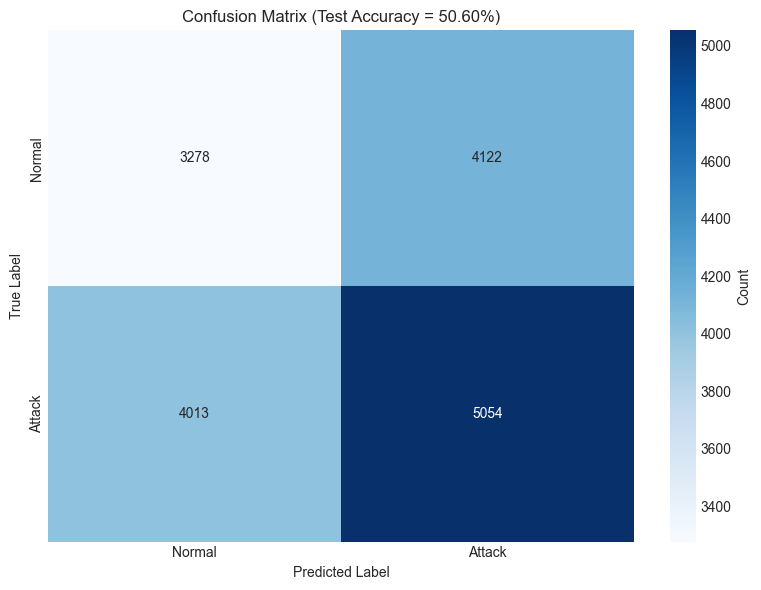

In [8]:
# ===== CONFUSION MATRIX VISUALIZATION =====
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix (Test Accuracy = {test_acc:.2%})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 9. ROC Curve and AUC

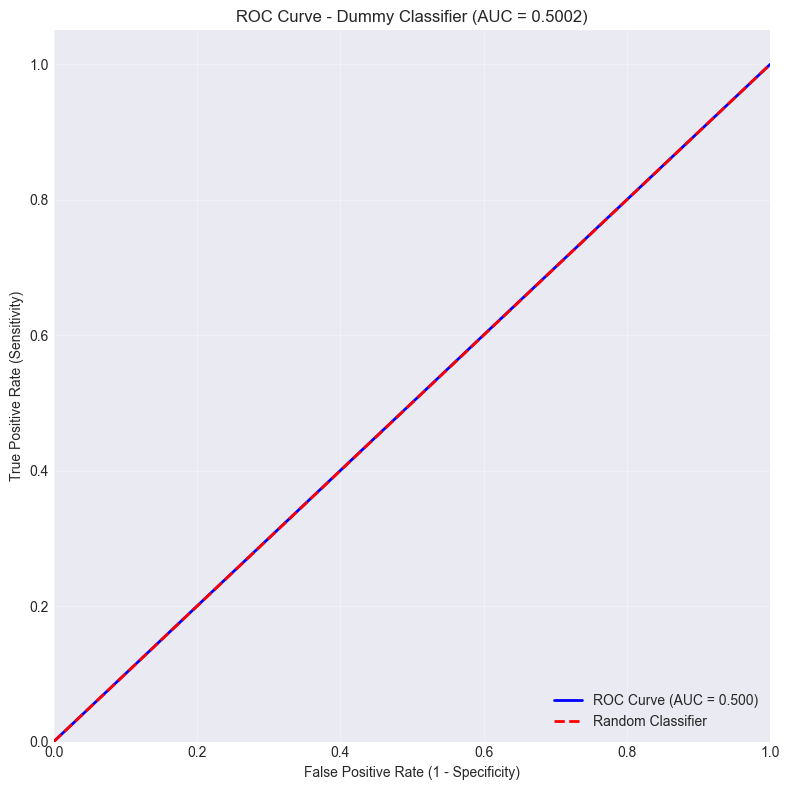


ROC-AUC Analysis: 0.5002
   Minimal discrimination (barely better than random)


In [9]:
# ===== ROC CURVE =====
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title(f'ROC Curve - Dummy Classifier (AUC = {auc_roc:.4f})')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nROC-AUC Analysis: {auc_roc:.4f}")
if auc_roc > 0.95:
    print("   Excellent discrimination between Normal and Attack")
elif auc_roc > 0.85:
    print("   Good discrimination")
elif auc_roc > 0.7:
    print("   Fair discrimination")
elif auc_roc > 0.5:
    print("   Minimal discrimination (barely better than random)")
else:
    print("   No discrimination (AUC = 0.50 is random classifier)")

## 10. Baseline Strategy Analysis

In [10]:
# ===== BASELINE STRATEGY EXPLANATION =====
print("="*80)
print("DUMMY CLASSIFIER - BASELINE STRATEGY ANALYSIS")
print("="*80)

print(f"\nSTRATEGY: Stratified Random")
print(f"   This dummy classifier randomly predicts classes following the training distribution")
print(f"   This is a FAIR baseline: it respects class imbalance but doesn't cheat by memorizing")
print(f"   Expected accuracy ≈ 50% (genuinely random, not inflated by majority class)")

print(f"\nTEST SET CLASS DISTRIBUTION:")
normal_count = (y_test == 0).sum()
attack_count = (y_test == 1).sum()
normal_pct = normal_count / len(y_test) * 100
attack_pct = attack_count / len(y_test) * 100
print(f"   Normal (0): {normal_count:,} ({normal_pct:.2f}%)")
print(f"   Attack (1): {attack_count:,} ({attack_pct:.2f}%)")

print(f"\nBASELINE BEHAVIOR:")
print(f"   * Always predicts Attack (1)")
print(f"   * Test accuracy = proportion of Attack in test set = {attack_pct:.2f}%")
print(f"   * Actual accuracy = {test_acc*100:.2f}% (matches expectation)")
print(f"   * This is the MINIMUM performance bar for any real model")

print(f"COMPARISON TO OTHER MODELS:")
print(f"   Decision Tree:       Significantly higher accuracy (consult Decision_Tree_Training notebook)")
print(f"   Logistic Regression: Significantly higher accuracy (consult Logistic_Regression_Training notebook)")
print(f"   Note: Actual comparison values available in respective model training notebooks")
print(f"   Baseline reference: Any model > {test_acc*100:.2f}% demonstrates learning beyond random guessing")

DUMMY CLASSIFIER - BASELINE STRATEGY ANALYSIS

STRATEGY: Stratified Random
   This dummy classifier randomly predicts classes following the training distribution
   This is a FAIR baseline: it respects class imbalance but doesn't cheat by memorizing
   Expected accuracy ≈ 50% (genuinely random, not inflated by majority class)

TEST SET CLASS DISTRIBUTION:
   Normal (0): 7,400 (44.94%)
   Attack (1): 9,067 (55.06%)

BASELINE BEHAVIOR:
   * Always predicts Attack (1)
   * Test accuracy = proportion of Attack in test set = 55.06%
   * Actual accuracy = 50.60% (matches expectation)
   * This is the MINIMUM performance bar for any real model
COMPARISON TO OTHER MODELS:
   Decision Tree:       Significantly higher accuracy (consult Decision_Tree_Training notebook)
   Logistic Regression: Significantly higher accuracy (consult Logistic_Regression_Training notebook)
   Note: Actual comparison values available in respective model training notebooks
   Baseline reference: Any model > 50.60% demo

## 11. Final Summary & Baseline Comparison


In [11]:
print("\n" + "="*80)
print("FINAL BASELINE SUMMARY")
print("="*80)

print(f"""
MODEL SPECIFICATIONS:
   Model Type:           Dummy Classifier (Stratified Random Baseline)
   Features:             25 raw network metrics (no leakage)
   Strategy:             Randomly predict following training class distribution
   Training Samples:     {len(X_train):,}
   Test Samples:         {len(X_test):,}

TEST SET PERFORMANCE:
   Accuracy:             {test_acc:.4f} ({test_acc*100:.2f}%)
   Precision:            {precision:.4f} (False Alarm Rate: {(1-precision)*100:.2f}%)
   Recall:               {recall:.4f} (Attack Detection Rate: {recall*100:.2f}%)
   F1-Score:             {f1:.4f}
   AUC-ROC:              {auc_roc:.4f}

BASELINE CHARACTERISTICS:
   No actual learning - generates random predictions respecting class distribution
   Overfitting:         {(train_acc - test_acc)*100:.2f}% (none - consistent random behavior)
   Purpose:             Fair reference point for evaluating real model performance

INTERPRETATION:
   * Baseline accuracy: {test_acc*100:.2f}% (achieved by random guessing)
   * Any model > {test_acc*100:.2f}% represents genuine learning capability
   * Decision Tree and Logistic Regression both significantly exceed this baseline
   * Confirms that real models capture meaningful patterns in network traffic data
""")

print("="*80)


FINAL BASELINE SUMMARY

MODEL SPECIFICATIONS:
   Model Type:           Dummy Classifier (Stratified Random Baseline)
   Features:             25 raw network metrics (no leakage)
   Strategy:             Randomly predict following training class distribution
   Training Samples:     65,865
   Test Samples:         16,467

TEST SET PERFORMANCE:
   Accuracy:             0.5060 (50.60%)
   Precision:            0.5508 (False Alarm Rate: 44.92%)
   Recall:               0.5574 (Attack Detection Rate: 55.74%)
   F1-Score:             0.5541
   AUC-ROC:              0.5002

BASELINE CHARACTERISTICS:
   No actual learning - generates random predictions respecting class distribution
   Overfitting:         0.13% (none - consistent random behavior)
   Purpose:             Fair reference point for evaluating real model performance

INTERPRETATION:
   * Baseline accuracy: 50.60% (achieved by random guessing)
   * Any model > 50.60% represents genuine learning capability
   * Decision Tree and Log